# EDA — Ipri

---
## 0. Configuración del Dataset

In [31]:
# ============================================================
# CONFIGURACIÓN: IPRI
# ============================================================

DATASET_CONFIG = {
    'nombre': 'ipri',
    'archivo': 'indice_precios_industriales_IPRI_bases_2021_2025.csv',
    'frecuencia_original': 'mensual',
    'col_fecha': 'fecha',
    'variable_principal': 'IPRI_total_industria_2025',
    'variables_desgloses': [
        'IPRI_energia_2025',
        'IPRI_bienes_equipo_2025',
        'IPRI_bienes_intermedios_2025',
        'IPRI_bienes_consumo_2025',
    ],
    'columnas_numericas': [
        'IPRI_total_industria_2025',
        'IPRI_industrias_extractivas_2025',
        'IPRI_industria_manufacturera_2025',
        'IPRI_energia_2025',
        'IPRI_bienes_equipo_2025',
        'IPRI_bienes_intermedios_2025',
        'IPRI_bienes_consumo_2025',
        ],
    'unidades': 'índice (base 2025=100)',
    'notas': 'INE. IPRI por sector y destino económico. Serie mensual desde 1975.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: ipri
Variable principal:  IPRI_total_industria_2025
Frecuencia:          mensual
Periodo estacional:  12


---
## Imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}

---
## 1. Carga y Diagnóstico Básico

In [33]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: ipri
Notas:   INE. IPRI por sector y destino económico. Serie mensual desde 1975.
Shape:          (610, 23)
Rango temporal: 1975-01-01 a 2025-10-01
Observaciones:  610
Columnas:       ['año', 'trimestre', 'periodo', 'IPRI_total_industria_2021', 'IPRI_industrias_extractivas_2021', 'IPRI_industria_manufacturera_2021', 'IPRI_suministro_energia_electrica_gas_vapor_aire_acondicionado_2021', 'IPRI_energia_2021', 'IPRI_bienes_equipo_2021', 'IPRI_bienes_intermedios_2021', 'IPRI_bienes_consumo_2021', 'IPRI_bienes_consumo_duradero_2021', 'IPRI_bienes_consumo_no_duradero_2021', 'IPRI_total_industria_2025', 'IPRI_industrias_extractivas_2025', 'IPRI_industria_manufacturera_2025', 'IPRI_suministro_energia_electrica_gas_vapor_aire_acondicionado_2025', 'IPRI_energia_2025', 'IPRI_bienes_equipo_2025', 'IPRI_bienes_intermedios_2025', 'IPRI_bienes_consumo_2025', 'IPRI_bienes_consumo_duradero_2025', 'IPRI_bienes_consumo_no_duradero_2025']


In [34]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,periodo,IPRI_total_industria_2021,IPRI_industrias_extractivas_2021,IPRI_industria_manufacturera_2021,IPRI_suministro_energia_electrica_gas_vapor_aire_acondicionado_2021,IPRI_energia_2021,IPRI_bienes_equipo_2021,IPRI_bienes_intermedios_2021,IPRI_bienes_consumo_2021,IPRI_bienes_consumo_duradero_2021,IPRI_bienes_consumo_no_duradero_2021,IPRI_total_industria_2025,IPRI_industrias_extractivas_2025,IPRI_industria_manufacturera_2025,IPRI_suministro_energia_electrica_gas_vapor_aire_acondicionado_2025,IPRI_energia_2025,IPRI_bienes_equipo_2025,IPRI_bienes_intermedios_2025,IPRI_bienes_consumo_2025,IPRI_bienes_consumo_duradero_2025,IPRI_bienes_consumo_no_duradero_2025
fecha,,,,,,,,,,,,,,,,,,,,,,,
1975-01-01,1975,1,1975Q1,10.800,11.340,11.840,6.030,6.040,11.870,13.000,12.040,13.450,11.760,8.608,9.391,9.960,4.544,4.540,10.497,11.406,9.688,11.959,9.414
1975-02-01,1975,1,1975Q1,11.010,12.390,12.060,6.850,6.830,12.200,13.140,12.120,13.450,11.920,8.775,10.261,10.145,5.162,5.134,10.789,11.529,9.753,11.959,9.542
1975-03-01,1975,1,1975Q1,11.080,12.560,12.060,6.890,6.890,12.370,13.140,12.200,13.450,11.920,8.831,10.401,10.145,5.192,5.179,10.939,11.529,9.817,11.959,9.542



Últimas 3 filas:


,año,trimestre,periodo,IPRI_total_industria_2021,IPRI_industrias_extractivas_2021,IPRI_industria_manufacturera_2021,IPRI_suministro_energia_electrica_gas_vapor_aire_acondicionado_2021,IPRI_energia_2021,IPRI_bienes_equipo_2021,IPRI_bienes_intermedios_2021,IPRI_bienes_consumo_2021,IPRI_bienes_consumo_duradero_2021,IPRI_bienes_consumo_no_duradero_2021,IPRI_total_industria_2025,IPRI_industrias_extractivas_2025,IPRI_industria_manufacturera_2025,IPRI_suministro_energia_electrica_gas_vapor_aire_acondicionado_2025,IPRI_energia_2025,IPRI_bienes_equipo_2025,IPRI_bienes_intermedios_2025,IPRI_bienes_consumo_2025,IPRI_bienes_consumo_duradero_2025,IPRI_bienes_consumo_no_duradero_2025
fecha,,,,,,,,,,,,,,,,,,,,,,,
2025-08-01,2025,3,2025Q3,125.300,120.930,118.550,133.230,133.060,113.070,113.410,124.300,112.720,124.940,99.865,100.146,99.723,100.396,100.013,99.992,99.501,100.020,100.228,100.014
2025-09-01,2025,3,2025Q3,124.670,121.320,118.790,128.830,130.410,113.290,113.220,124.810,112.740,125.470,99.363,100.469,99.925,97.081,98.021,100.186,99.335,100.430,100.246,100.438
2025-10-01,2025,4,2025Q4,125.340,121.420,118.550,133.330,132.750,113.540,112.940,125.010,112.900,125.670,99.897,100.551,99.723,100.472,99.780,100.408,99.089,100.591,100.388,100.598


In [35]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
IPRI_total_industria_2025,0,0.000,1975-01-01,2025-10-01
IPRI_industrias_extractivas_2025,0,0.000,1975-01-01,2025-10-01
IPRI_industria_manufacturera_2025,0,0.000,1975-01-01,2025-10-01
IPRI_energia_2025,0,0.000,1975-01-01,2025-10-01
IPRI_bienes_equipo_2025,0,0.000,1975-01-01,2025-10-01
IPRI_bienes_intermedios_2025,0,0.000,1975-01-01,2025-10-01
IPRI_bienes_consumo_2025,0,0.000,1975-01-01,2025-10-01



Duplicados de fecha: 0


In [36]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 31 days 00:00:00
Intervalo mínimo:                      28 days 00:00:00
Intervalo máximo:                      31 days 00:00:00


---
## 2. Series Temporales

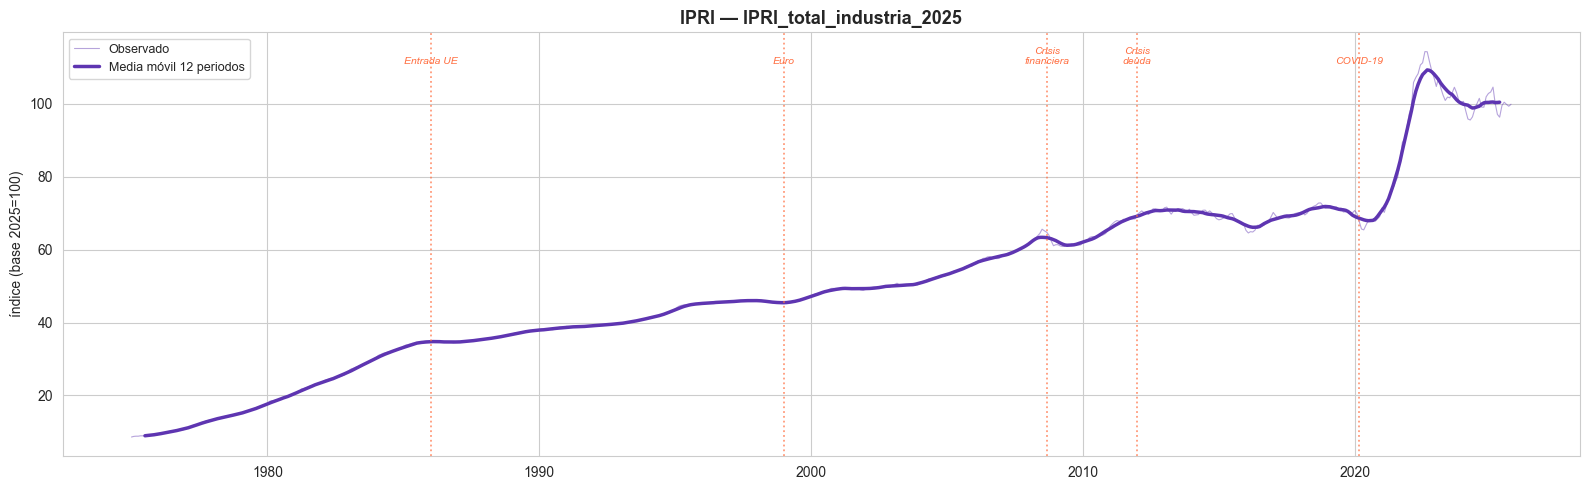

Mín: 8.61  (1975-01-01)
Máx: 114.35  (2022-08-01)


In [37]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

El `IPRI_total_industria_2025` (Índice de Precios Industriales con base 2025) describe una trayectoria ascendente de largo plazo desde un mínimo de 8,61 en enero de 1975 hasta un máximo histórico de 114,35 en agosto de 2022, con una dinámica sustancialmente distinta a la del `IPC_2025`: mientras el IPC acumula inflación de forma casi monótona, el IPRI presenta una meseta prolongada entre 1999 y 2020 y un pico abrupto en 2021-2022 que domina visualmente la serie.

Se distinguen tres fases. La primera, entre 1975 y 1999, es de crecimiento sostenido desde aproximadamente 9 hasta aproximadamente 45 puntos (base 2025=100), reflejo de la inflación de costes industriales del periodo de la Transición y la modernización productiva tras la entrada en la CEE en 1986. La segunda, entre 1999 y 2020, es de estabilización relativa en torno a 45-70 puntos, con dos ciclos visibles: una subida hasta aproximadamente 70 en 2008 impulsada por el boom de materias primas, una caída posterior asociada al desplome de los precios energéticos en 2009, y una recuperación gradual hasta aproximadamente 68 en 2019. Esta estabilización contrasta con la inflación al consumo del mismo periodo y refleja la moderación de los precios de producción en un contexto de globalización y competencia internacional de manufacturas. La tercera fase, desde 2020, es la más relevante para la modelización: el índice se dispara desde aproximadamente 68 hasta el máximo histórico de 114,35 en agosto de 2022, un incremento de aproximadamente el 68% en menos de dos años, impulsado por el shock energético y de materias primas post-pandémico y agravado por la invasión de Ucrania en febrero de 2022. La posterior corrección hasta aproximadamente 98-100 refleja la normalización parcial de los precios energéticos, con el índice convergiendo hacia la base de referencia al final de la muestra.

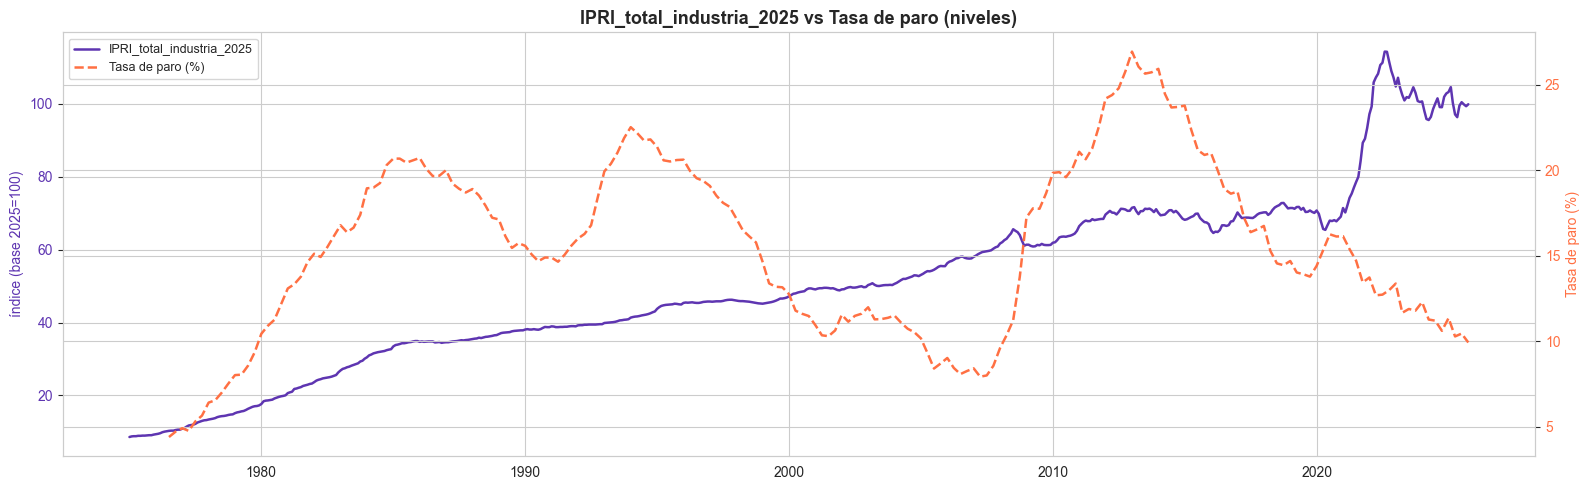

In [38]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación en niveles entre el `IPRI_total_industria_2025` y la tasa de paro no presenta un signo contemporáneo estable: el índice describe una trayectoria ascendente casi monótona mientras el paro sigue un perfil cíclico, de modo que la lectura conjunta queda dominada por la deriva común y no por una relación estructural. Entre 1976 y 1985 ambas series suben a la vez (el IPRI pasa de aproximadamente 9 a 35 puntos y el paro de aproximadamente 4% a 21%), un co-movimiento positivo asociado a la inflación de costes y a la destrucción de empleo de la reconversión industrial. Entre 1985 y 2007 la relación se vuelve predominantemente inversa: el IPRI continúa su ascenso gradual hasta aproximadamente 50 puntos mientras el paro, tras el pico del 24% en 1994, retrocede hasta el entorno del 8% en 2007. El tramo 2008-2013 rompe el patrón: el índice se estabiliza en una meseta próxima a 70 puntos al tiempo que el paro escala hasta aproximadamente 27%, sin co-movimiento definido. Desde 2014 el IPRI permanece en esa meseta y después se dispara hasta el máximo histórico de 114 en 2022, mientras el paro desciende de forma sostenida hasta aproximadamente 10%, con la divergencia más acusada de toda la muestra durante el shock energético de 2021-2022. La correlación en niveles es, por tanto, espuria por la tendencia compartida; el análisis cuantitativo se realiza en la sección 9 sobre la forma estacionaria.

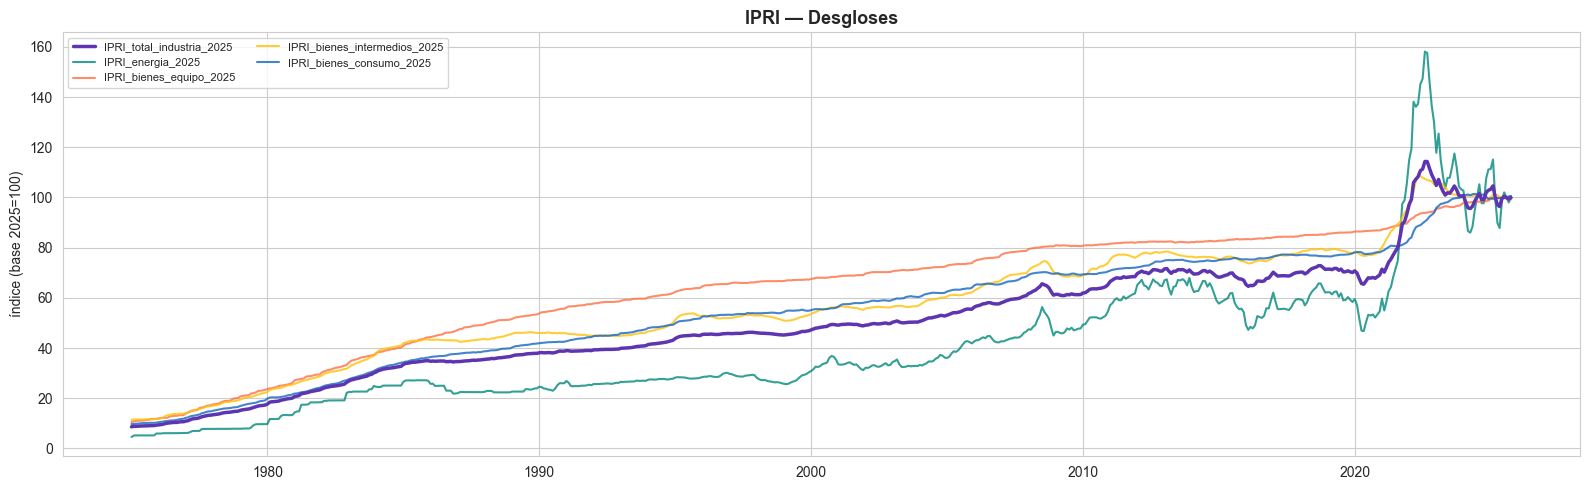

In [39]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=2.5, label=VAR_PRINCIPAL, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(UNIDADES, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

El desglose por destino económico revela que el `IPRI_total_industria_2025` está dominado por la dinámica del componente energético, responsable de la práctica totalidad de la volatilidad y del pico de 2021-2022. El `IPRI_energia_2025` alcanza un máximo de aproximadamente 158 en 2022, mientras el agregado total culmina en 114,35 en el mismo periodo, lo que sitúa la amplitud relativa del shock energético en un factor aproximadamente 1,4 veces superior al del índice total y en un orden de magnitud sin equivalente en ningún otro componente. El `IPRI_bienes_intermedios_2025`, el `IPRI_bienes_consumo_2025` y el `IPRI_bienes_equipo_2025` siguen trayectorias mucho más suaves, con picos de 2022 contenidos por debajo de 115 y sin oscilaciones de alta frecuencia comparables a las del componente energético.

Hasta aproximadamente 1985 las cinco series se mueven de forma cohesionada en una banda estrecha entre aproximadamente 5 y 15 puntos, reflejo de una estructura industrial donde la energía no estaba liberalizada y los precios de todos los componentes respondían a la misma dinámica inflacionista general del periodo de la Transición. A partir de 1985 el componente energético se desacopla visiblemente del resto, con oscilaciones de mayor amplitud que reflejan la progresiva liberalización de los mercados energéticos y la exposición directa a los precios internacionales del petróleo y el gas. Los ciclos del `IPRI_energia_2025` en 2008 (subida hasta aproximadamente 55 seguida de caída brusca tras Lehman) y 2014-2016 (descenso hasta aproximadamente 40 por el desplome del Brent) no tienen reflejo proporcional en los demás componentes, confirmando que la energía opera como variable parcialmente exógena respecto al resto de precios industriales.

El periodo 2020-2025 concentra el shock más severo de toda la muestra y revela un patrón de transmisión asimétrica con implicaciones estructurales. El `IPRI_energia_2025` se dispara desde aproximadamente 55 en 2020 hasta el máximo de aproximadamente 158 en agosto de 2022, casi triplicando su nivel en dos años por la combinación de cuellos de botella post-pandémicos, la invasión de Ucrania y la crisis logística asociada. Los componentes no energéticos absorbieron el shock con intensidades distintas: `IPRI_bienes_intermedios_2025` y `IPRI_bienes_consumo_2025` alcanzaron picos próximos a 110-115 en 2022, mientras `IPRI_bienes_equipo_2025` apenas superó los 100, dado su menor peso de costes energéticos y su mayor exposición a la competencia internacional manufacturera. La corrección posterior confirma el efecto ratchet característico de los precios industriales: el componente energético devuelve más de la mitad de la subida y cierra la muestra en torno a 95, pero los componentes no energéticos no descienden proporcionalmente y se estabilizan cerca de 100-105 en 2024-2025. El hecho de que los componentes no energéticos cierren la muestra al nivel de la base 2025 implica que el salto de costes inducido por el shock energético se ha consolidado de forma persistente en los precios de producción, lo que justifica metodológicamente mantener la base 2025 como referencia: la histéresis inflacionista post-COVID no es un episodio transitorio sino el nuevo régimen de precios industriales.

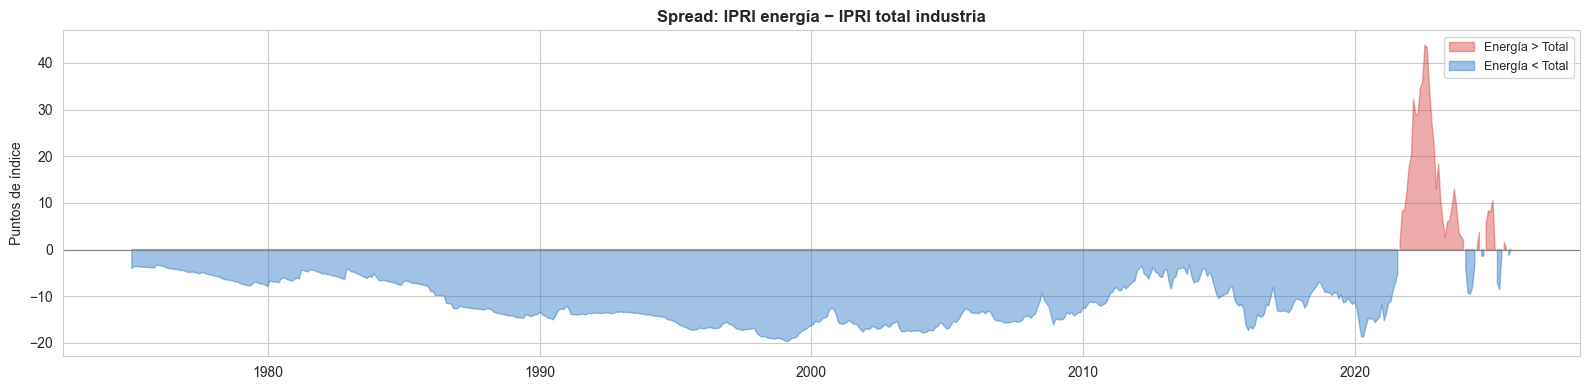

In [40]:
# Spread energía vs total industria
if 'IPRI_energia_2025' in df.columns and 'IPRI_total_industria_2025' in df.columns:
    spread_energia = df['IPRI_energia_2025'] - df['IPRI_total_industria_2025']

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.fill_between(spread_energia.index, spread_energia, 0,
                     where=spread_energia >= 0, color='#D32F2F', alpha=0.4, label='Energía > Total')
    ax.fill_between(spread_energia.index, spread_energia, 0,
                     where=spread_energia < 0, color='#1565C0', alpha=0.4, label='Energía < Total')
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_title('Spread: IPRI energía − IPRI total industria', fontsize=12, fontweight='bold')
    ax.set_ylabel('Puntos de índice', fontsize=10)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

### Análisis:

El spread entre `IPRI_energia_2025` e `IPRI_total_industria_2025` permanece en terreno negativo durante prácticamente todo el periodo 1976-2020, con valores comprendidos entre -5 y -20 puntos de índice, lo que indica que los precios energéticos industriales se mantuvieron sistemáticamente por debajo del nivel general del IPRI durante más de cuatro décadas. Este resultado refleja que la inflación acumulada de los componentes de bienes de equipo, intermedios y consumo fue superior a la del componente energético durante el largo periodo de industrialización y modernización productiva española, un patrón contrario al que podría anticiparse a partir de los shocks del petróleo de 1973 y 1979, cuyos efectos sobre el IPRI energético fueron absorbidos por la estructura de precios regulados y el rezago en la liberalización del mercado.

El único episodio de inversión del spread es el shock de 2021-2022: el `IPRI_energia_2025` supera al total en hasta aproximadamente 44 puntos en el pico de la crisis, el mayor diferencial positivo de toda la muestra y cuantitativamente incomparable con cualquier episodio anterior. Esta magnitud confirma la excepcionalidad del shock energético post-pandémico y su papel como perturbación exógena de oferta sin precedente en la historia del IPRI español. La corrección posterior es rápida: el spread retorna hacia cero y alterna entre terreno ligeramente positivo y ligeramente negativo en 2023-2025, sin recuperar la banda de -10 a -20 puntos que caracterizó el periodo 1985-2020.

Esta incapacidad del spread para retornar a su régimen histórico negativo es la expresión más directa del efecto ratchet documentado en el análisis de desgloses: los componentes no energéticos han absorbido de forma persistente parte del shock de costes, elevando su nivel relativo y produciendo una recomposición estructural del IPRI. Para la modelización, esta ruptura de régimen implica que las relaciones históricas entre el IPRI energético y el total industrial previas a 2020 tienen validez reducida en el tramo más reciente de la muestra.

---
## 3. Distribución y Outliers

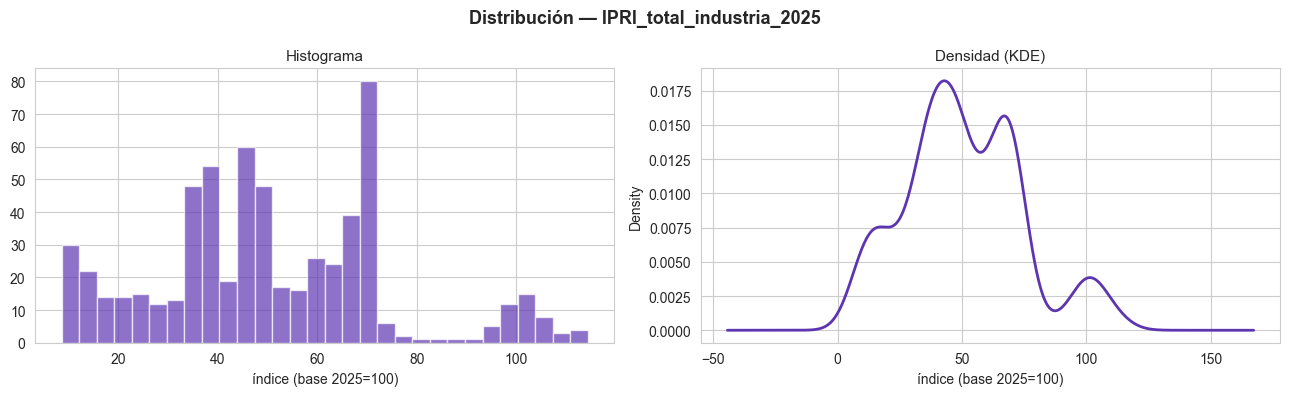

Asimetría (skewness): 0.405
Curtosis:             -0.023


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

`IPRI_total_industria_2025` presenta una distribución asimétrica hacia la derecha con un cuerpo principal entre 10 y 75 puntos y un pequeño cluster secundario en torno a 95-105. El cuerpo principal no es unimodal limpio: el histograma revela varios picos locales en torno a 15, 45, 50 y especialmente 65-70 (la barra más alta, con aproximadamente 80 observaciones), que el suavizado del KDE agrega en dos máximos visibles, uno en aproximadamente 45 y otro en aproximadamente 65. Esta estructura interna refleja la sedimentación de las distintas fases del régimen inflacionista español documentadas en el análisis de la serie principal, no una verdadera bimodalidad: no existe un valle pronunciado dentro del cuerpo, sino una sucesión de modas locales separadas por descensos menores. El cluster secundario en 95-105 sí queda claramente desconectado del cuerpo principal por un tramo de muy baja densidad entre aproximadamente 75 y 90, pero su masa es notablemente menor (en torno a 15 observaciones frente a 80 en el pico del cuerpo principal), lo que corresponde mejor a un hombro derecho pronunciado que a una segunda moda comparable.

Los estadísticos confirman esta lectura. La asimetría positiva de 0,405 es moderada y se explica por la cola derecha generada por las observaciones del shock 2021-2022, no por una bimodalidad estructural. La curtosis prácticamente nula (-0,023) refuerza la interpretación: una distribución genuinamente bimodal con dos modas separadas y de magnitud comparable habría producido curtosis negativa por reparto de masa entre dos picos, y un shock con observaciones muy extremas habría producido curtosis positiva por acumulación en colas. La ausencia de ambos efectos indica que las colas son normales y que la estructura interna del cuerpo se promedia hacia algo razonablemente próximo a una distribución estándar en sus momentos de orden superior.

Estos resultados son consistentes con la naturaleza de la serie: el cluster derecho (`IPRI_total_industria_2025` entre 95 y 115) no son outliers estadísticos sino el tramo final de una serie tendencial, las observaciones más recientes del periodo 2021-2025. Para la modelización, este patrón implica que el nivel del IPRI no es adecuado como regresor sin transformación previa: trabajar con la variación interanual (diff 4 trimestral) o intertrimestral (diff 1) elimina simultáneamente la tendencia, la asimetría y la estructura multimodal residual, dejando una distribución mucho más cercana a la normalidad requerida por la mayoría de especificaciones econométricas.

In [42]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha   valor
1975-01-01   8.608
1975-02-01   8.775
1975-03-01   8.831
1975-04-01   8.831
1975-05-01   8.934
2022-06-01 110.665
2022-07-01 111.294
2022-10-01 111.629
2022-09-01 114.299
2022-08-01 114.347


### Análisis:

La ausencia total de outliers tanto por IQR como por z-score en una serie con un rango de aproximadamente 8,6 a 114,3 puntos es el hallazgo central: no porque la serie carezca de valores extremos en sentido económico, sino porque ambos métodos los absorben por razones estructurales distintas.

El criterio IQR no detecta outliers porque la distribución, aunque asimétrica y con estructura interna compleja, tiene una dispersión suficientemente gradual como para que los bigotes de 1,5×IQR alcancen los extremos de la muestra: la tendencia ascendente de largo plazo dilata el rango intercuartílico hasta el punto en que ningún valor queda fuera de los límites. El criterio z-score tampoco detecta anomalías porque los valores extremos de los dos extremos temporales (mínimos en 1975, máximos en 2022) son simétricamente opuestos en relación a la media y se compensan parcialmente en la varianza total, que al ser elevada deja todos los valores dentro de las tres desviaciones típicas. Este resultado contrasta con el EDA de parados, donde el criterio IQR identificó 15 outliers concentrados en la crisis 2012-2015, precisamente porque esa serie no tiene tendencia monótona y los episodios cíclicos sobresalen sobre un nivel medio más estable.

Los 10 valores extremos confirman que los mínimos corresponden exclusivamente a los primeros meses de la muestra (enero a mayo de 1975, entre 8,608 y 8,934) y los máximos al pico del shock energético (junio a octubre de 2022, entre 110,665 y 114,347), con el máximo absoluto en agosto de 2022 con un valor de 114,347. Ambos grupos son extremos temporales de la tendencia, no anomalías respecto a la dinámica local de la serie. Para la modelización, la ausencia de outliers estadísticos es una propiedad del nivel de la serie pero no de sus variaciones: la primera diferencia o la variación interanual del `IPRI_total_industria_2025` sí producirá valores extremos detectables en el entorno de 2021-2022, que deberán tratarse explícitamente en la especificación del modelo.

In [43]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

El diagrama de dispersión por década refuerza el carácter condicionado al régimen de la relación. La nube de puntos se concentra de forma marcada en torno a `Δ1` ≈ 0 (la inmensa mayoría de los cambios intertrimestrales de precios industriales son pequeños, dentro de una banda de aproximadamente ±2 puntos), con una única cola horizontal extendida hacia la derecha (`Δ1` de hasta aproximadamente +10) formada en exclusiva por los puntos de los años 2020, los del shock energético post-pandémico. La recta de tendencia global es casi plana con una pendiente ligeramente negativa, coherente con la correlación global de -0,068: para el conjunto de la muestra, un mayor cambio de precios industriales se asocia a un nivel de paro apenas inferior, una señal demasiado débil para tener valor predictivo.

La estratificación por color es la lectura más informativa: las décadas se separan netamente en el eje vertical (nivel de paro) y no en el horizontal (`Δ1`). Los años 1970 se sitúan en la franja de paro bajo (aproximadamente 5-10%), mientras los 1980, 1990 y 2010 ocupan la franja alta (aproximadamente 15-27%), los 2000 una posición intermedia (aproximadamente 8-12%) y los 2020 el tramo de 10-16% pero con la cola horizontal del shock. Que la dispersión vertical la determine la década, es decir el régimen macroeconómico, y no el valor de `Δ1`, confirma que para un mismo cambio de precios industriales próximo a cero el desempleo recorre todo su rango histórico: la relación contemporánea entre ambas variables es esencialmente nula y está dominada por el régimen.

### Análisis:

La distribución por mes del `IPRI_total_industria_2025` no presenta patrón estacional discernible. Las 12 cajas son virtualmente idénticas en mediana (en torno a 50 puntos), rango intercuartílico (aproximadamente 35-65) y extensión de los bigotes (aproximadamente 10-110 en todos los meses), sin desplazamiento sistemático de ningún mes respecto al resto. Esta homogeneidad contrasta con el boxplot mensual de variables EPA como ocupados o inactivos, donde el tercer trimestre mostraba un desplazamiento claro asociado al empleo estival y a los flujos clasificatorios de estudiantes.

La ausencia de estacionalidad en el nivel del IPRI es coherente con la naturaleza de la serie: un índice de precios de producción industrial refleja contratos, costes de materias primas y márgenes que se negocian y trasladan de forma continua a lo largo del año, sin la concentración temporal que caracteriza al empleo turístico o agrícola. Los shocks de oferta (energía, materias primas) afectan al IPRI con retardos variables dictados por los mercados internacionales, no por el calendario estacional doméstico. Este resultado anticipa que la descomposición STL no extraerá un componente estacional relevante y que el resampleo trimestral mediante media no introducirá distorsión significativa por eliminación de variación intra-trimestral.

---
## 4. Estacionalidad

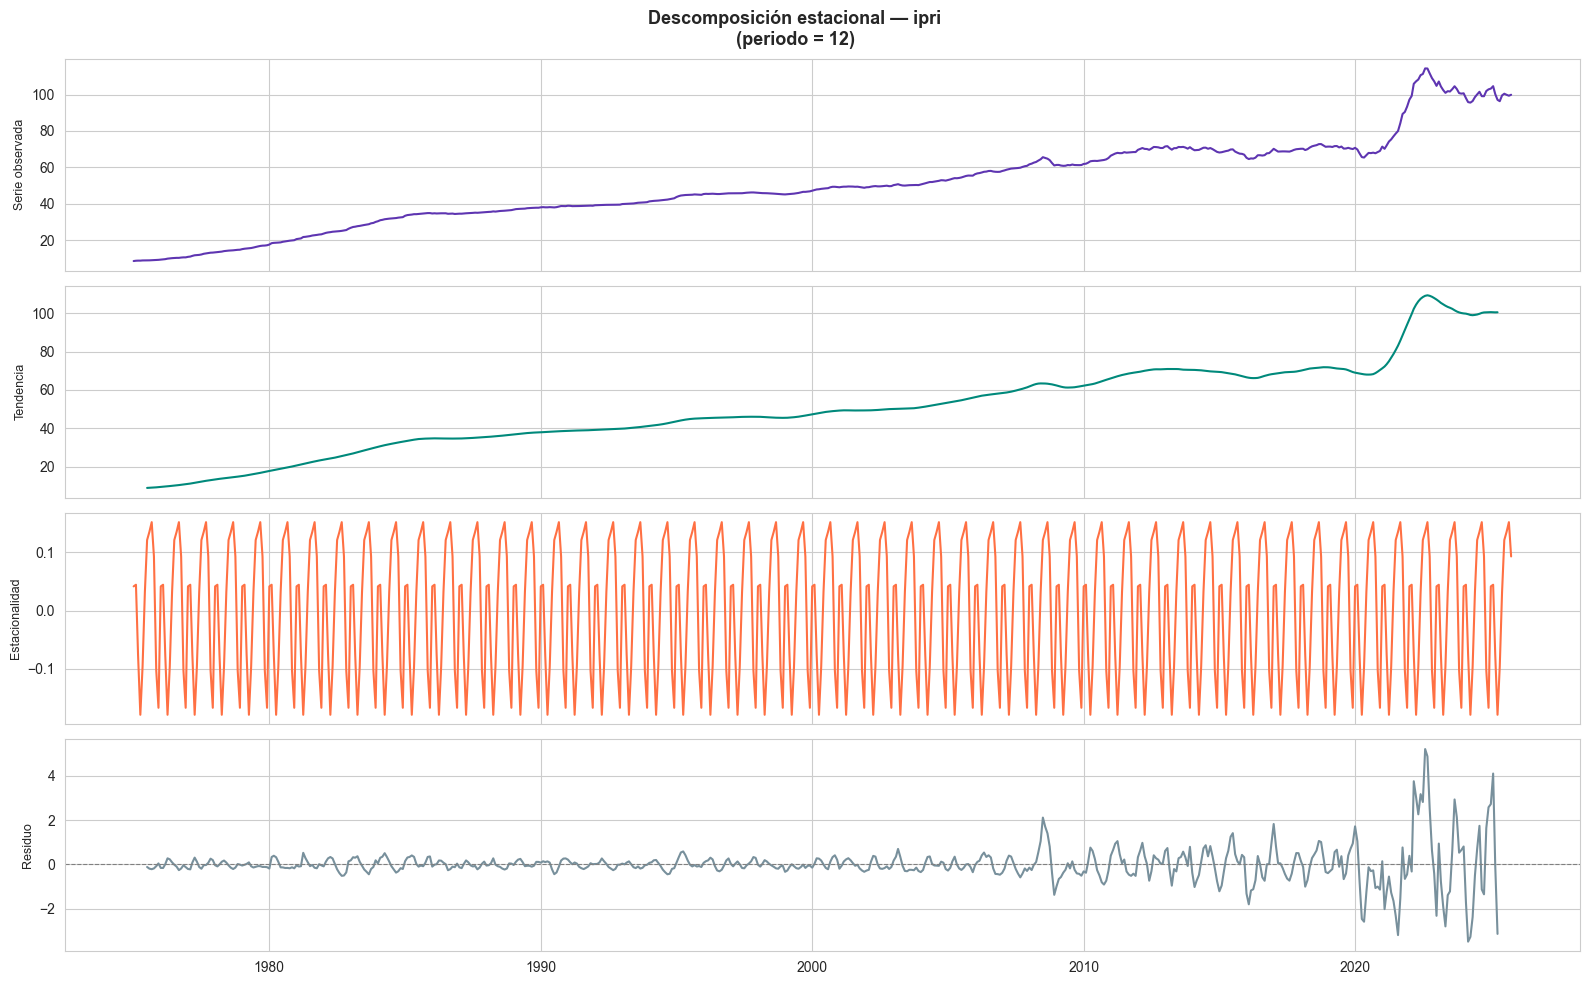

In [44]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición STL con periodo 12 confirma cuantitativamente lo anticipado por el boxplot mensual: el componente estacional del `IPRI_total_industria_2025` es irrelevante en magnitud. La amplitud estacional oscila entre aproximadamente -0,15 y +0,15 puntos de índice a lo largo de toda la muestra, lo que sobre una serie que recorre un rango de 8,6 a 114,3 puntos representa menos del 0,3% del nivel medio. Esta proporción es incluso inferior a la documentada para el `IPC_2025` (CV entre trimestres de 0,76%) y confirma que los precios industriales no están sujetos a un calendario estacional doméstico relevante.

La tendencia captura la práctica totalidad de la dinámica de la serie: el ascenso gradual desde aproximadamente 15 hasta 70 entre 1975 y 2020, la aceleración abrupta hasta aproximadamente 105 en 2022, y la corrección posterior hasta aproximadamente 100. La suavidad de la tendencia STL incluso en el tramo 2020-2022 indica que el filtro absorbe el shock energético como un cambio de nivel permanente, no como una perturbación transitoria, coherente con la interpretación de histéresis inflacionista formulada en el análisis de desgloses.

El componente residual es el panel más informativo para la caracterización de la serie. Los residuos permanecen prácticamente nulos y homocedásticos entre 1975 y aproximadamente 2005, con valores contenidos en una banda de ±0,5 puntos. A partir de 2008 la volatilidad se amplifica de forma visible, con picos de aproximadamente ±2 puntos durante la crisis financiera. El tramo 2020-2025 concentra los residuos de mayor magnitud de toda la muestra, con valores que alcanzan aproximadamente +5 y -3 puntos, reflejando las perturbaciones de alta frecuencia del shock energético que la tendencia no alcanza a absorber completamente. Esta heterocedasticidad de los residuos, con una ruptura clara a partir de 2008, queda documentada como una característica de la serie; su tratamiento se difiere a las fases de feature engineering y modelización.

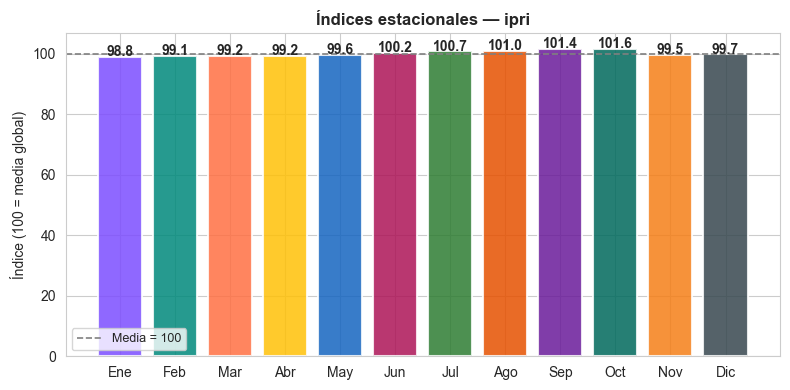

Índices estacionales:
Ene    98.800
Feb    99.100
Mar    99.200
Abr    99.200
May    99.600
Jun   100.200
Jul   100.700
Ago   101.000
Sep   101.400
Oct   101.600
Nov    99.500
Dic    99.700

Periodo con mayor ipri: Oct (101.6)
Periodo con menor ipri: Ene (98.8)


In [45]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

Los índices estacionales cuantifican con precisión la irrelevancia de la estacionalidad anticipada en el boxplot y la descomposición STL. El rango total entre el mes de mayor índice (octubre, 101,6) y el de menor (enero, 98,8) es de apenas 2,8 puntos porcentuales sobre la media global, una amplitud sin interpretación económica sustantiva para un índice de precios industriales.

El patrón, en la medida en que existe, describe un nivel marginalmente inferior en el primer semestre (enero a mayo, índices entre 98,8 y 99,6) y algo más elevado entre junio y octubre (100,2 a 101,6), con una corrección en noviembre y diciembre (99,5 y 99,7). La magnitud es tan reducida que no justifica elaboración causal: un diferencial máximo de 2,8 puntos sobre 100 queda dentro del ruido estadístico de una serie con un rango de 8,6 a 114,3 puntos. La estacionalidad del `IPRI_total_industria_2025` es, en consecuencia, prescindible para la caracterización de la serie: el resampleo trimestral por media la absorbe de forma natural y no aporta estructura que deba arrastrarse a las fases posteriores.

---
## 5. Cambios Periodo a Periodo

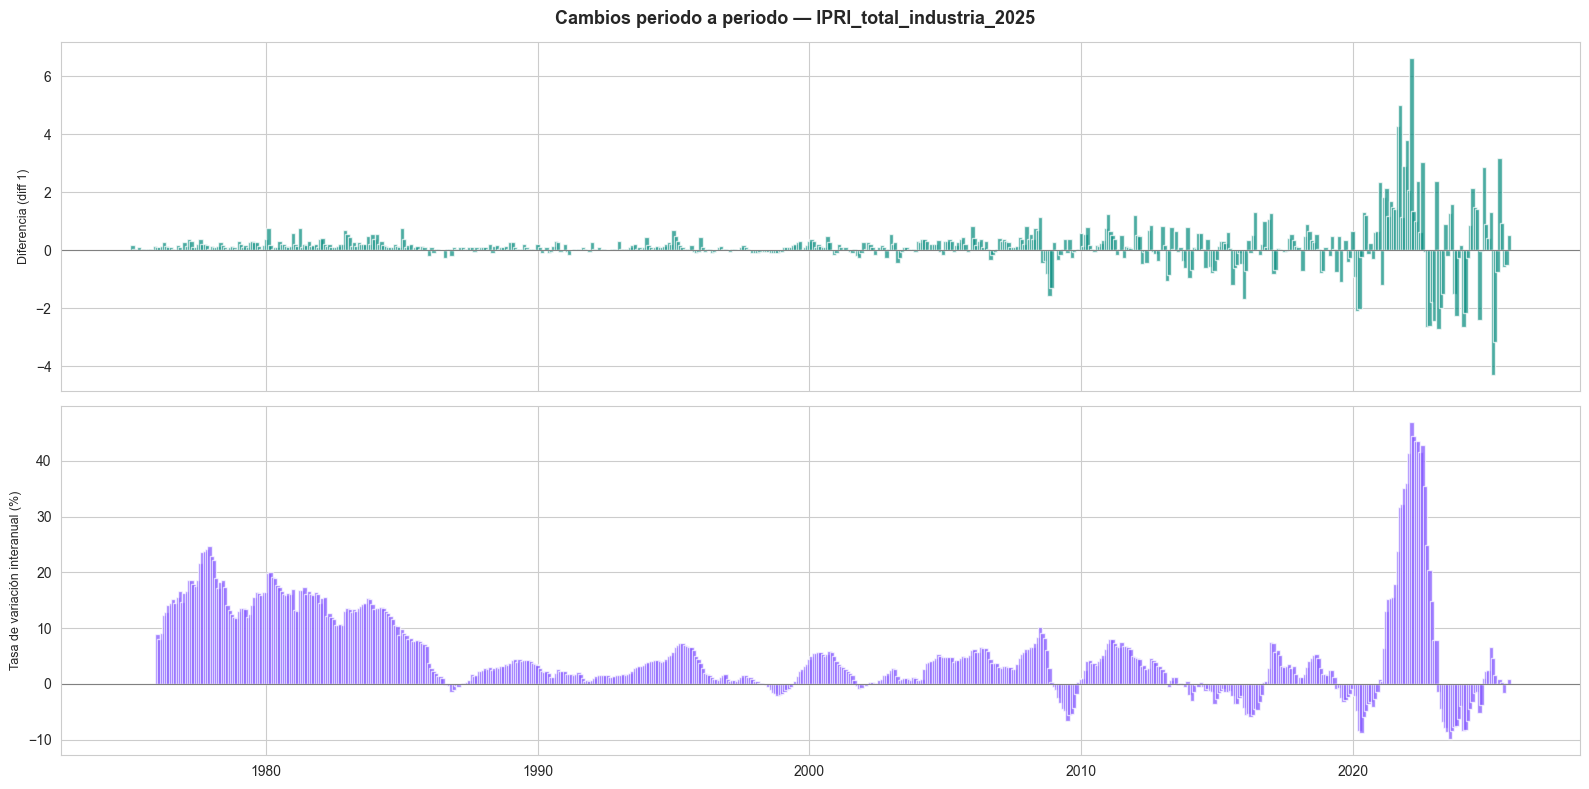

Estadísticas de la variación interanual (%):
count   598.000
mean      5.260
std       8.100
min      -9.950
25%       0.660
50%       3.170
75%       7.410
max      46.970


In [46]:
diff1 = y.diff(1).dropna()
diff_est = ((y / y.shift(PERIODO_ESTACIONAL) - 1) * 100).dropna()  # variación interanual %  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

La variación interanual del `IPRI_total_industria_2025` presenta una distribución marcadamente asimétrica hacia la derecha, con una media de 5,26% frente a una mediana de 3,17%, y un máximo histórico de 46,97% que corresponde al pico del shock energético de 2022. El mínimo de -9,95% refleja los episodios de deflación industrial de 2009 y el desplome de la demanda post-COVID en 2020, ambos visibles en el panel inferior como las únicas barras claramente negativas de la muestra.

La diferencia primera (panel superior) revela una heterocedasticidad progresiva coherente con lo observado en el residuo de la descomposición STL. Entre 1975 y aproximadamente 2005 los cambios mensuales se mantienen en una banda estrecha de ±0,5 puntos, con mínima dispersión. A partir de 2008 la amplitud se incrementa, con valores que alcanzan aproximadamente ±2,5 puntos durante la crisis financiera. El tramo 2020-2025 concentra los extremos absolutos: el máximo de aproximadamente +6,5 puntos y el mínimo de aproximadamente -4,5 puntos, ambos en el entorno inmediato del pico de agosto de 2022. La varianza de la primera diferencia no es, por tanto, constante a lo largo de la muestra; esta heterocedasticidad queda documentada como característica de la serie y su tratamiento se difiere a las fases de feature engineering y modelización.

La variación interanual (panel inferior) distingue tres grandes episodios de inflación industrial que difieren no solo en intensidad sino en naturaleza: el periodo 1975-1985 refleja tasas sostenidas entre 10% y 25% propias de una economía en transición con inflación estructural, el ciclo 2004-2008 muestra un repunte moderado entre 5% y 10% impulsado por el boom de materias primas, y el shock de 2021-2022 alcanza un 46,97%, una escala sin precedente en la muestra y de carácter exógeno. La desviación típica de 8,10 puntos porcentuales, alta respecto a la mediana de 3,17%, refleja la dominancia estadística de este último episodio sobre la distribución agregada. La elección de la forma con que la serie entrará en los modelos se resuelve en el bloque de estacionariedad (sección 6): conviene anticipar que la variación interanual porcentual, pese a su lectura económica directa como inflación industrial, no supera el test de estacionariedad por la persistencia de su autocorrelación, mientras que la primera diferencia sí lo hace de forma limpia.

---
## 6. Estacionariedad y Autocorrelación

In [47]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'ct'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (var interanual %)', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                                       serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           IPRI_total_industria_2025 (nivel)         ct     0.123  0.968           False      0.204   0.015             True NO ESTACIONARIA
          IPRI_total_industria_2025 (diff 1)          c    -7.601  0.000            True      0.056   0.100            False    ESTACIONARIA
IPRI_total_industria_2025 (var interanual %)          c    -3.643  0.005            True      0.727   0.011             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  IPRI_total_industria_2025 (nivel)  (KPSS regression='ct')
    ADF  (H₀ = raíz unitaria):  stat=0.123, p=0.9676 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.204, p=0.0147 (rechaza H₀)
    → NO ESTACIONARIA

  IPRI_total_industria_2025 (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-7.601, p=0.0000 (rechaza H₀)

### Análisis:

En niveles, ambos tests convergen en un diagnóstico claro de no estacionariedad: el ADF no rechaza la raíz unitaria (stat=0,123, p=0,9676) y el KPSS rechaza la estacionariedad (stat=0,204, p=0,0147). El estadístico ADF positivo y cercano a cero es particularmente informativo, ya que indica que la serie ni siquiera se aproxima a la región de rechazo, resultado esperable para un índice de precios con tendencia ascendente dominante como la documentada en la serie principal.

La primera diferencia produce un diagnóstico limpio de estacionariedad: el ADF rechaza contundentemente la raíz unitaria (stat=-7,601, p=0,0000) y el KPSS no rechaza la estacionariedad (stat=0,056, p=0,1000). La variación interanual porcentual, en cambio, no es estacionaria: aunque el ADF rechaza la raíz unitaria (stat=-3,643, p=0,0050), el KPSS rechaza la estacionariedad (stat=0,727, p=0,0111), una discrepancia que se resuelve por criterio conservador como no estacionariedad y que es coherente con la fuerte persistencia de la autocorrelación de esta transformación. Conviene distinguir la variación interanual porcentual (relativa, que divide por el nivel) de la diferencia interanual absoluta: no son la misma transformación a efectos de estacionariedad, y es la versión absoluta la que se valida en el bloque trimestral siguiente.

Este resultado es más limpio que el obtenido para varias series EPA, donde la contaminación del outlier de 2020-Q2 producía discrepancias entre ADF y KPSS en primera diferencia. La ausencia de contradicción del `IPRI_total_industria_2025` en primera diferencia indica que, pese a la heterocedasticidad documentada en los residuos STL y en la propia diferencia, la estructura de la serie no presenta los picos clasificatorios abruptos que complicaban el diagnóstico de las variables de población. La caracterización operativa a frecuencia trimestral, que es la del modelo, se valida en el bloque 6.1.

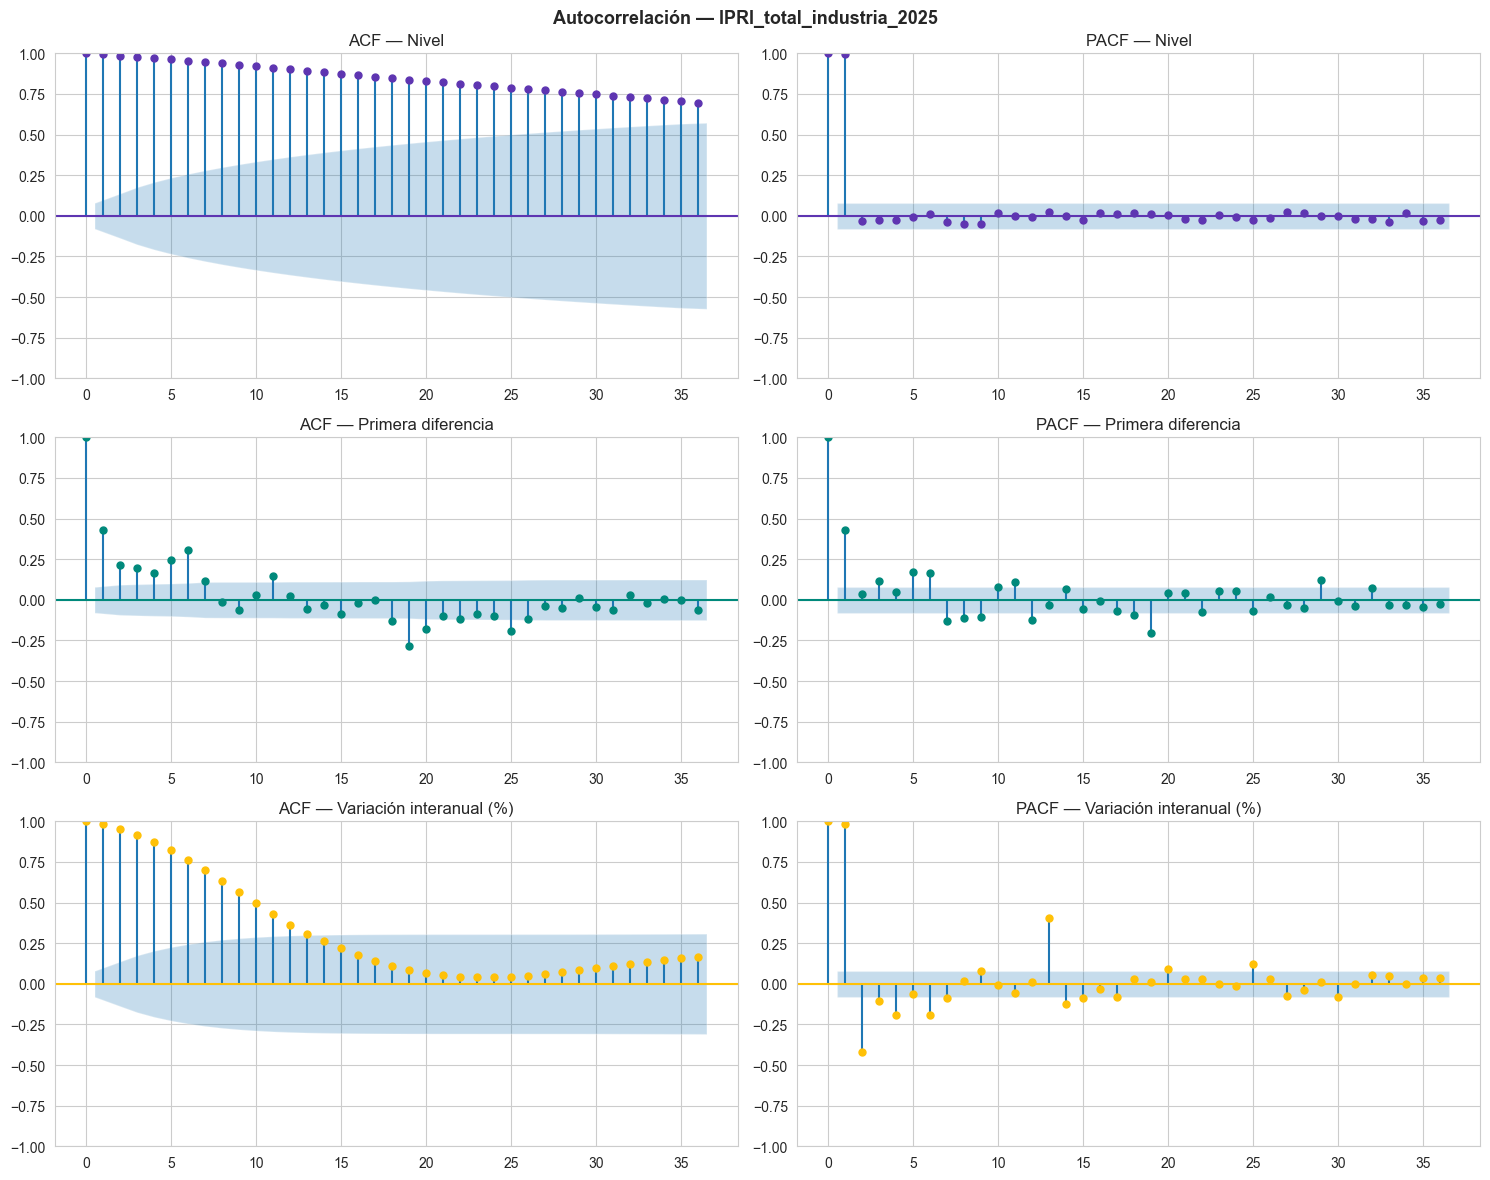

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title='ACF — Variación interanual (%)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title='PACF — Variación interanual (%)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles, el correlograma confirma la no estacionariedad diagnosticada por los tests formales. La ACF decae de forma extremadamente lenta desde valores próximos a 1,0, manteniéndose significativa más allá del lag 35, mientras la PACF muestra un único pico dominante en el lag 1 (cercano a 1,0) con todos los lags posteriores dentro de la banda de significancia. Este patrón conjunto, ACF con decaimiento lento y PACF con corte abrupto tras el lag 1, es la firma de un proceso AR(1) con raíz cercana a la unidad, coherente con el estadístico ADF positivo (0,123) y con la tendencia ascendente dominante de la serie.

Tras la primera diferencia, la estructura de autocorrelación cambia radicalmente. La ACF presenta un pico significativo en el lag 1 (aproximadamente 0,45), seguido de picos menores pero todavía significativos en los lags 3, 5 y 11, con un pico negativo notable en torno al lag 18-19 (aproximadamente -0,25). La PACF muestra un patrón similar: pico en el lag 1 (aproximadamente 0,45), un segundo pico en el lag 3 (aproximadamente 0,25) y lags posteriores mayoritariamente dentro de la banda. El hecho de que ambas funciones decaigan de forma gradual sin un corte limpio apunta a un proceso ARMA mixto en la serie diferenciada, no a un AR o MA puro. La persistencia en el lag 1, con coeficientes de aproximadamente 0,45 tanto en ACF como en PACF, indica una inercia mensual considerable en los cambios de precios industriales: un incremento en un mes tiende a prolongarse parcialmente en el siguiente. No se observa un patrón claro a múltiplos de 12, lo que confirma la ausencia de estacionalidad mensual residual tras la diferenciación y es consistente con la amplitud negligible del componente estacional en la descomposición STL.

### 6.1 Validación a frecuencia trimestral

El bloque previo de tests caracteriza la serie a su frecuencia original, donde la información es más rica. La modelización del paro, sin embargo, opera a frecuencia trimestral (target EPA), por lo que las transformaciones operativas deben validarse a esa misma frecuencia.

Este bloque verifica que las conclusiones sobre estacionariedad se trasladan correctamente a la serie resampleada (por media trimestral, coherente con la naturaleza de la variable), sobre la que opera el modelo. Se evalúan las mismas cuatro transformaciones que a frecuencia original:
- nivel trimestral
- `Δ1` trimestral (cambio intertrimestral)
- `Δ4` trimestral (cambio interanual)
- variación interanual porcentual trimestral

In [49]:
# Resampleo a frecuencia trimestral
LAGS_ACF_Q = 16
METODO_Q = 'media'
y_q = df[VAR_PRINCIPAL].resample('QS').mean().dropna()

diff1_q = y_q.diff(1).dropna()
diff4_q = y_q.diff(4).dropna()
pct_q = ((y_q / y_q.shift(4) - 1) * 100).dropna()

series_test_q = [
    (y_q, f'{VAR_PRINCIPAL} trimestral (nivel)', 'ct'),
    (diff1_q, f'{VAR_PRINCIPAL} trimestral (Δ1)', 'c'),
    (diff4_q, f'{VAR_PRINCIPAL} trimestral (Δ4)', 'c'),
    (pct_q, f'{VAR_PRINCIPAL} trimestral (var interanual %)', 'c'),
]

resultados_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_q])

print(f'Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: {METODO_Q}):')
print('=' * 85)
print(resultados_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: media):
                                                  serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           IPRI_total_industria_2025 trimestral (nivel)         ct     0.288  0.977           False      0.140   0.061            False NO ESTACIONARIA
              IPRI_total_industria_2025 trimestral (Δ1)          c    -4.977  0.000            True      0.052   0.100            False    ESTACIONARIA
              IPRI_total_industria_2025 trimestral (Δ4)          c    -3.244  0.018            True      0.067   0.100            False    ESTACIONARIA
IPRI_total_industria_2025 trimestral (var interanual %)          c    -2.415  0.138           False      0.594   0.023             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  IPRI_total_industria_2025 trimestral (nivel)  (KPSS regression='ct')
    ADF  stat=0.288, p=0.9768 (NO 

### Análisis:

La validación a frecuencia trimestral confirma el diagnóstico de la frecuencia original y lo precisa. El nivel sigue siendo no estacionario (ADF stat=0,288, p=0,9768; KPSS stat=0,140, p=0,0610), si bien el KPSS trimestral ya no rechaza con claridad, efecto de la pérdida de potencia al reducir la muestra de 610 observaciones mensuales a 204 trimestres. La primera diferencia `Δ1` se mantiene estacionaria con holgura (ADF stat=-4,977, p=0,0000; KPSS stat=0,052, p=0,1000), aunque con un estadístico ADF menos extremo que el mensual (-4,977 frente a -7,601), de nuevo por la menor potencia a frecuencia trimestral. La diferencia interanual absoluta `Δ4` también resulta estacionaria (ADF stat=-3,244, p=0,0176; KPSS stat=0,067, p=0,1000), lo que la habilita como transformación interanual operativa para el cruce con el paro.

La variación interanual porcentual, en cambio, se confirma no estacionaria en las dos frecuencias (KPSS stat=0,594, p=0,0234 a frecuencia trimestral; stat=0,727 a frecuencia mensual): el ADF la acepta pero el KPSS la rechaza por la persistencia de su autocorrelación. El cuadro trimestral deja por tanto dos formas estacionarias disponibles, `Δ1` y `Δ4`, y descarta la variación porcentual. Las propiedades del proceso no cambian al resamplear; lo que cambia es la capacidad de los tests para distinguirlas, algo más limpia en `Δ1` por la reducción de varianza residual.

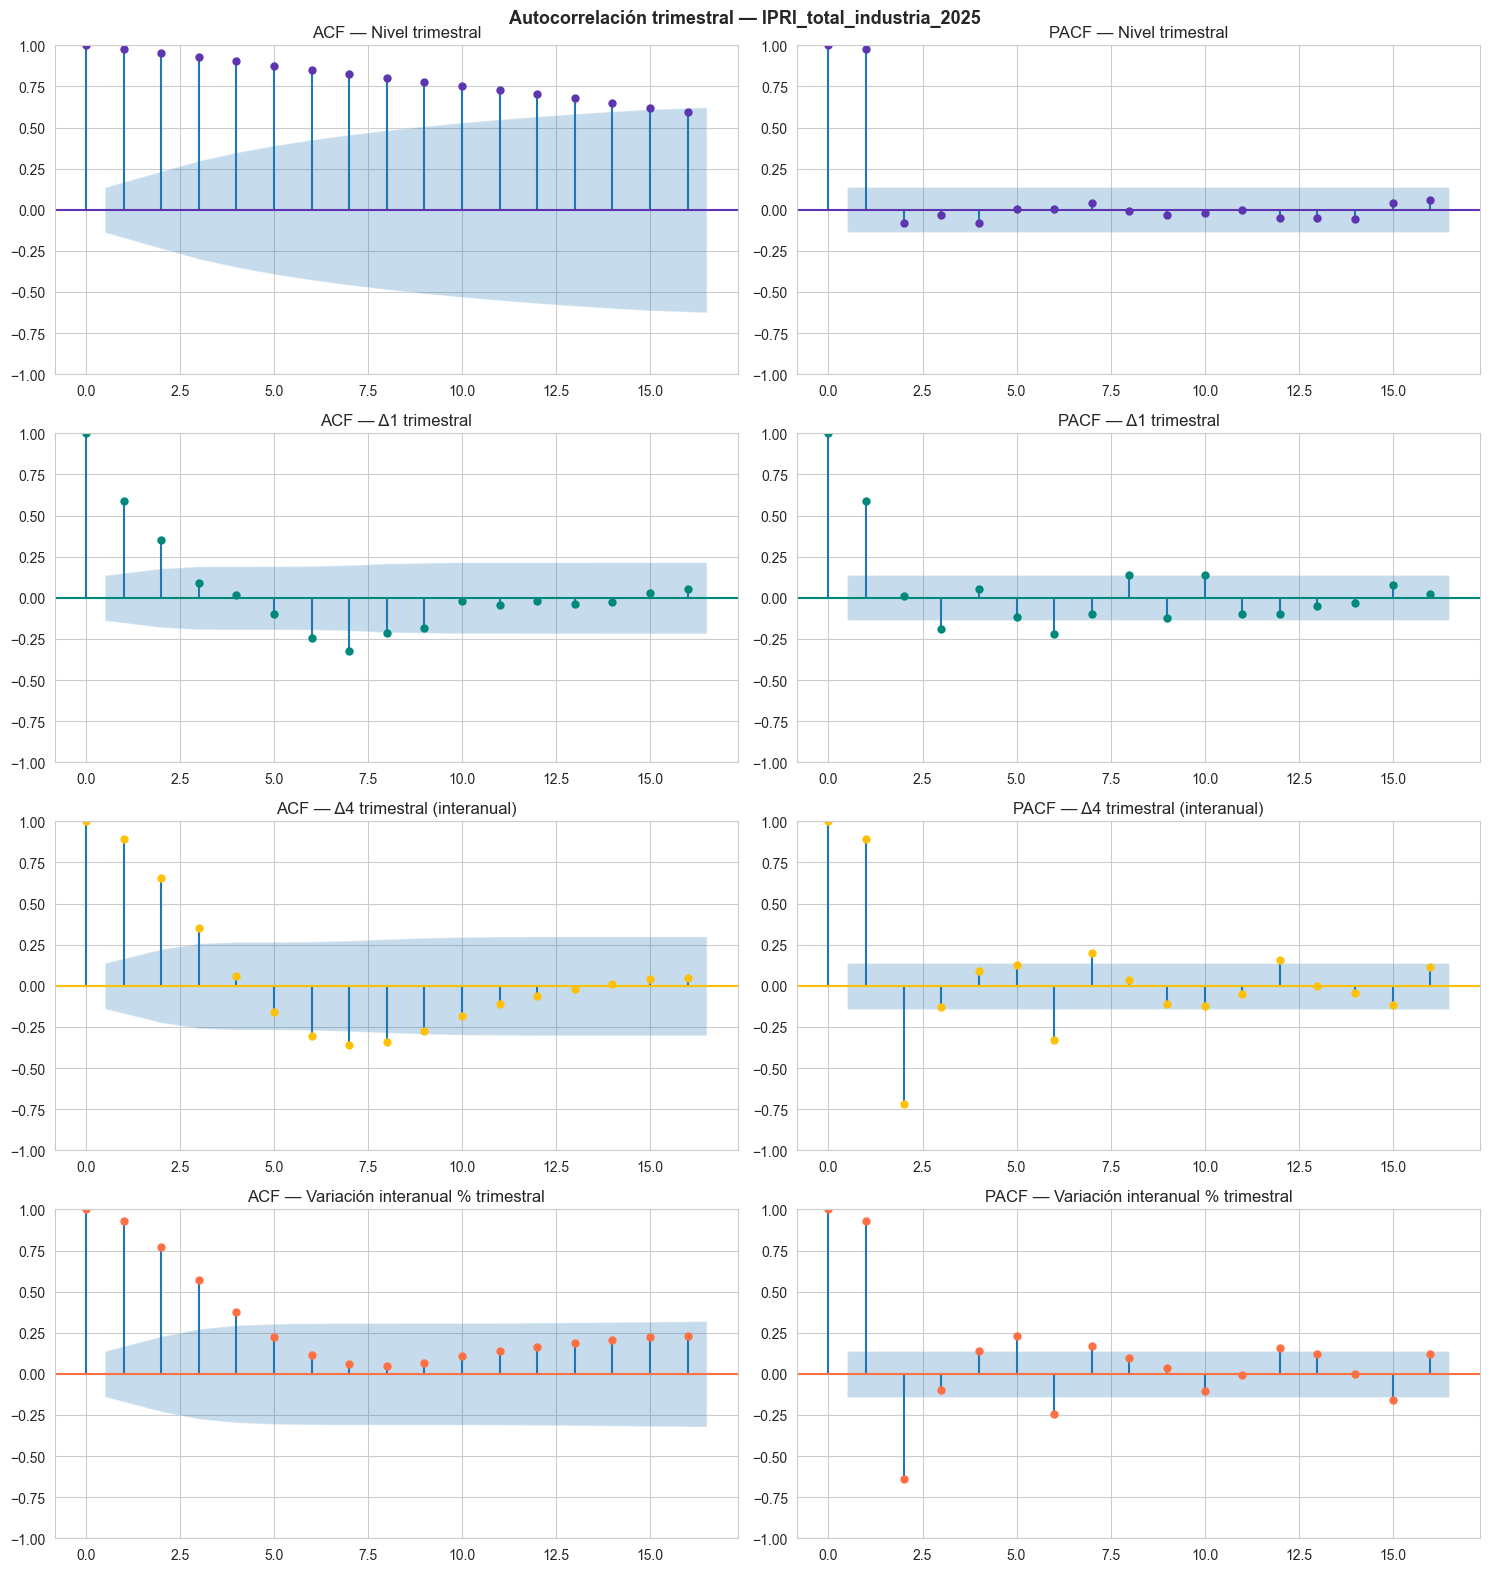

In [50]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación trimestral — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel trimestral')
plot_pacf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel trimestral', method='ywm')
plot_acf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#00897B',
         title='ACF — Δ1 trimestral')
plot_pacf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#00897B',
          title='PACF — Δ1 trimestral', method='ywm')
plot_acf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 0], color='#FFC107',
         title='ACF — Δ4 trimestral (interanual)')
plot_pacf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 1], color='#FFC107',
          title='PACF — Δ4 trimestral (interanual)', method='ywm')
plot_acf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual % trimestral')
plot_pacf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual % trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

La estructura de autocorrelación a frecuencia trimestral reproduce la de la frecuencia mensual y refuerza el diagnóstico de los tests. En nivel, la ACF decae muy lentamente desde valores próximos a 1 (en torno a 0,60 todavía en el lag 16) y la PACF concentra toda la señal en un pico dominante en el lag 1 cercano a la unidad, el patrón canónico de un AR(1) con raíz próxima a 1 propio de una serie no estacionaria.

La primera diferencia `Δ1` reduce drásticamente la persistencia: la ACF muestra un pico en el lag 1 de aproximadamente 0,60 y otro en el lag 2 de aproximadamente 0,35, seguidos de un tramo de coeficientes negativos en los lags 5 a 9, mientras la PACF se concentra en el lag 1 y entra en banda a partir del lag 2. Es el perfil de un proceso con inercia trimestral de corto alcance y sin estructura estacional dominante en múltiplos de 4. La diferencia interanual `Δ4` presenta una ACF que parte de un lag 1 elevado (aproximadamente 0,88) y decae de forma gradual con coeficientes negativos en los lags 6 a 9, y una PACF con un pico fuerte en el lag 1 seguido de un valor marcadamente negativo en el lag 2 (aproximadamente -0,72), estructura característica de la sobrediferenciación que introduce el filtro interanual y compatible con la estacionariedad que confirman los tests.

La variación interanual porcentual, en cambio, exhibe una ACF de decaimiento lento que permanece en torno a 0,25 en el lag 16 y una PACF dominada por el lag 1 (aproximadamente 0,95). Esta persistencia es la firma gráfica de la no estacionariedad que el KPSS detecta y confirma que, a diferencia de la diferencia interanual absoluta, la versión porcentual no estabiliza la serie.

In [51]:
# Estacionalidad trimestral reconstruida desde y_q
if len(y_q) >= 8:
    colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107']
    df_box_q = pd.DataFrame({
        'trimestre': y_q.index.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}),
        'valor': y_q.values,
        'fecha': y_q.index.strftime('%Y-%m-%d'),
    })
    df_box_q['trimestre'] = pd.Categorical(df_box_q['trimestre'],
                                            categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)
    fig = px.box(
        df_box_q, x='trimestre', y='valor', color='trimestre',
        hover_data=['fecha'],
        title=f'Estacionalidad trimestral — {VAR_PRINCIPAL}',
        labels={'valor': UNIDADES, 'trimestre': 'Trimestre'},
        color_discrete_sequence=colores_bp,
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()

    medias_q = y_q.groupby(y_q.index.quarter).mean()
    cv_trimestral = medias_q.std() / medias_q.mean() * 100 if medias_q.mean() != 0 else 0
    medias_dict = {k: round(float(v), 3) for k, v in medias_q.items()}
    print('Media por trimestre:', medias_dict)
    estac = '(estacionalidad apreciable)' if cv_trimestral > 5 else '(estacionalidad leve)'
    print(f'CV entre trimestres: {cv_trimestral:.2f}% {estac}')

Media por trimestre: {1: 50.026, 2: 50.361, 3: 51.056, 4: 51.31}
CV entre trimestres: 1.18% (estacionalidad leve)


### Análisis:

La estacionalidad trimestral del `IPRI_total_industria_2025` es prácticamente nula. Las cuatro cajas son visualmente indistinguibles en mediana (en torno a 49 puntos), rango intercuartílico (aproximadamente de 35 a 68) y extensión de los bigotes, sin desplazamiento sistemático de ningún trimestre. Las medias por trimestre se separan por apenas 1,3 puntos (Q1 50,026, Q2 50,361, Q3 51,056, Q4 51,310), con un leve ascenso monótono de Q1 a Q4 sin relevancia práctica, y el coeficiente de variación entre trimestres es de apenas 1,18%, confirmación de una estacionalidad leve. La amplitud de cada caja, que abarca desde valores próximos a 10 hasta cerca de 110, no refleja oscilación estacional sino la tendencia secular del índice a lo largo de toda la muestra. Este resultado es coherente con la estacionalidad negligible ya documentada en frecuencia mensual (amplitud STL de ±0,15 puntos, índices estacionales entre 98,8 y 101,6) y confirma que el resampleo trimestral por media no introduce ni elimina patrón estacional alguno.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [52]:
df_der = pd.DataFrame(index=df.index)

if all(c in df.columns for c in ['IPRI_energia_2025', 'IPRI_total_industria_2025']):
    df_der['prima_energia'] = df['IPRI_energia_2025'] - df['IPRI_total_industria_2025']

if all(c in df.columns for c in ['IPRI_bienes_equipo_2025', 'IPRI_bienes_consumo_2025']):
    df_der['spread_equipo_consumo'] = df['IPRI_bienes_equipo_2025'] - df['IPRI_bienes_consumo_2025']

df_der['ipri_yoy'] = df['IPRI_total_industria_2025'].pct_change(12) * 100

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (3):


,prima_energia,spread_equipo_consumo,ipri_yoy
count,610.000,610.000,598.000
mean,-9.813,8.403,5.259
std,8.289,4.062,8.103
min,-19.693,-3.418,-9.946
25%,-14.951,6.589,0.663
50%,-12.211,9.379,3.167
75%,-6.307,11.532,7.405
max,43.767,13.644,46.975


### Análisis:

Se han construido tres variables derivadas, cada una orientada a capturar una dimensión distinta de la dinámica de precios industriales relevante para la predicción del paro.

`prima_energia` (diferencia entre `IPRI_energia_2025` e `IPRI_total_industria_2025`) reproduce en frecuencia mensual el spread analizado gráficamente. Su media de -9,813 puntos y mediana de -12,211 puntos confirman que el componente energético se sitúa sistemáticamente por debajo del agregado durante la mayor parte de la muestra, con un rango que va desde -19,693 (máximo dominio del total sobre energía) hasta 43,767 (pico del shock de 2021-2022). La asimetría entre el mínimo y el máximo, con una desviación típica de 8,289, refleja la misma distribución sesgada ya documentada en el análisis del spread: el régimen histórico negativo es estable y de baja volatilidad, mientras el episodio positivo es breve, extremo y sin precedente.

`spread_equipo_consumo` (diferencia entre `IPRI_bienes_equipo_2025` e `IPRI_bienes_consumo_2025`) captura la divergencia relativa entre los dos componentes no energéticos de menor y mayor exposición a los costes domésticos. Su media de 8,403 y mediana de 9,379 indican que los bienes de equipo han cotizado históricamente por encima de los bienes de consumo en términos de índice, aunque el rango entre el percentil 25 (6,589) y el 75 (11,532) es relativamente estrecho. El mínimo de -3,418 señala episodios puntuales de inversión del diferencial, coherentes con los periodos de transmisión asimétrica de costes energéticos identificados en el análisis de desgloses.

`ipri_yoy` (variación interanual) ya fue interpretada en el análisis de cambios periodo a periodo, con media de 5,259%, mediana de 3,167% y máximo de 46,975%. Es la transformación principal para la modelización y la única de las tres directamente estacionaria según los tests formales.

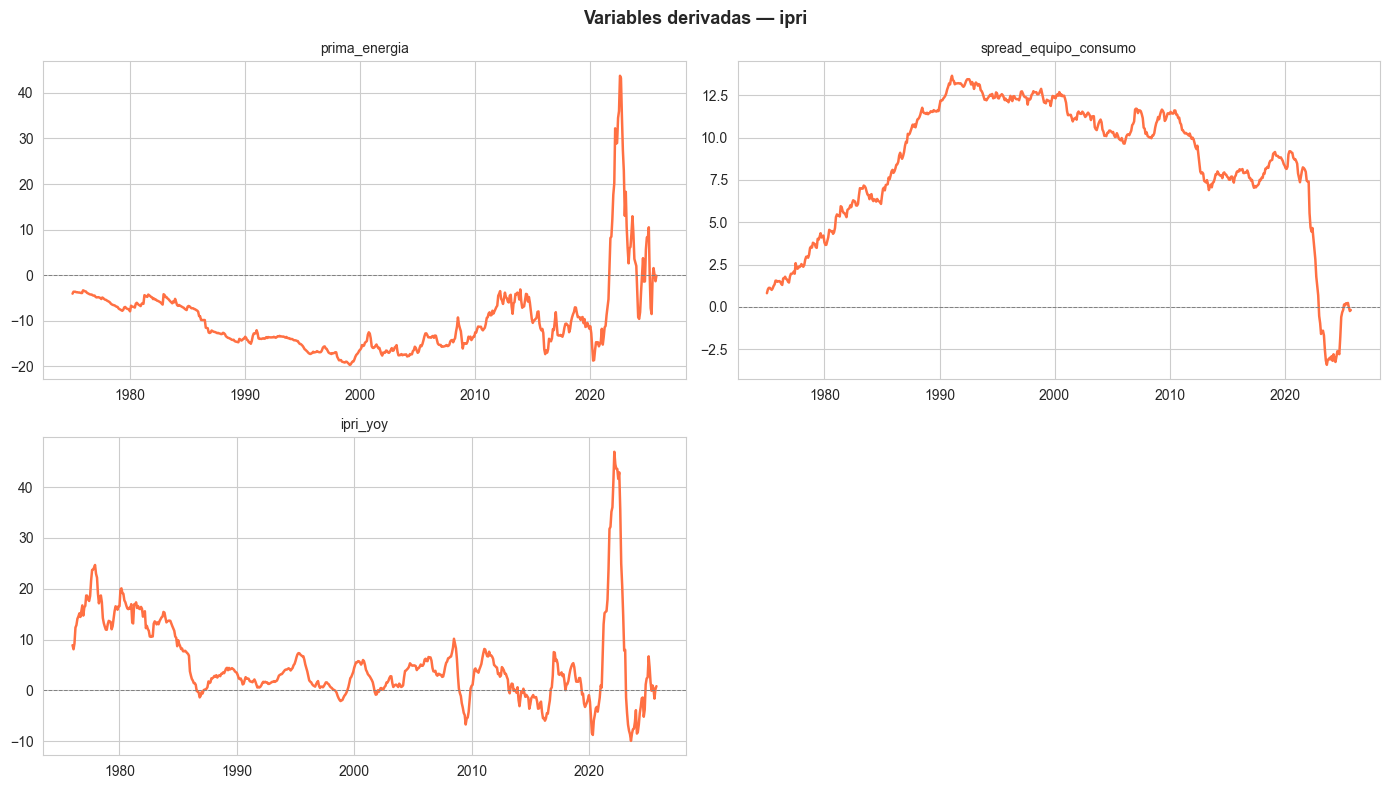

In [53]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

`prima_energia` muestra un comportamiento estable en régimen negativo (-10 a -20 puntos) desde 1975 hasta 2020, con oscilaciones cíclicas visibles en torno a 2008 (subida hasta aproximadamente -5 por el boom de materias primas seguida de caída brusca por el desplome energético post-Lehman) y 2014-2016 (descenso hasta aproximadamente -18 por el desplome del Brent). El pico positivo de 43,767 en 2022 es el único episodio en toda la muestra en que la energía supera al total industrial, y su carácter vertical y aislado confirma que se trata de una perturbación exógena de oferta sin precedente, no de un cambio estructural gradual. La corrección posterior es rápida pero incompleta: la serie no regresa al régimen histórico de -15 a -20 puntos sino que oscila en torno a -5 a 0, consistente con el efecto ratchet documentado en los desgloses.

`spread_equipo_consumo` describe una trayectoria muy distinta: ascenso gradual desde aproximadamente 1 en 1975 hasta el máximo de aproximadamente 13 a principios de los 90, seguido de una meseta larga hasta 2010 y una tendencia descendente hasta 2020. El colapso hasta el mínimo de -3,418 en 2022-2023 es el único episodio de inversión del diferencial en toda la muestra y refleja que el shock energético post-pandémico elevó los precios de bienes de consumo (más expuestos a costes domésticos de energía y transporte) por encima de los de bienes de equipo (más internacionalizados y con mayor absorción de costes vía márgenes). La posterior recuperación parcial hacia 0 en 2024-2025 sugiere una normalización incipiente pero incompleta.

`ipri_yoy` muestra tres episodios de inflación industrial positiva elevada ya descritos en el análisis de cambios periodo a periodo, y añade visualmente un detalle relevante: el pico negativo de -9,946 en 2020 es tan abrupto como el positivo de 46,975 en 2022 y refleja la deflación industrial del confinamiento, un episodio simétrico en velocidad pero opuesto en signo que el gráfico pone en perspectiva: la caída de 2020 y la subida de 2022 forman juntas el mayor ciclo de volatilidad interanual de toda la historia del IPRI español.

In [54]:
# ── Guardar dataset enriquecido (trimestral) ───────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]

# Remuestrear a frecuencia trimestral
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32']]
df_trimestral = df[cols_num].resample('QS').mean()
df_trimestral = df_trimestral.dropna(how='all')

# Guardar CSV trimestral
ruta_q = ruta.parent / (ruta.stem + '_trimestral.csv')
df_trimestral.to_csv(ruta_q)
print(f'CSV trimestral guardado: {ruta_q.name}')
print(f'  Columnas: {len(df_trimestral.columns)}')
print(f'  Rango: {df_trimestral.index.min().date()} — {df_trimestral.index.max().date()}')
print(f'  Observaciones: {len(df_trimestral)} trimestres')


CSV trimestral guardado: indice_precios_industriales_IPRI_bases_2021_2025_trimestral.csv
  Columnas: 25
  Rango: 1975-01-01 — 2025-10-01
  Observaciones: 204 trimestres


---
## 8. Tabla Resumen

In [55]:
est_q_nivel = resultados_q[resultados_q['serie'].str.contains('nivel')]['conclusion'].values[0]
est_q_d1 = resultados_q[resultados_q['serie'].str.contains('Δ1')]['conclusion'].values[0]
est_q_d4 = resultados_q[resultados_q['serie'].str.contains('Δ4')]['conclusion'].values[0]
est_q_pct = resultados_q[resultados_q['serie'].str.contains('var interanual')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

q1q, q3q = y_q.quantile(0.25), y_q.quantile(0.75)
iqr_q = q3q - q1q
outliers_q = y_q[(y_q < q1q - 1.5 * iqr_q) | (y_q > q3q + 1.5 * iqr_q)]

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            f'trimestral (resampleo: {METODO_Q})',
    'N obs original':        f"{len(y.dropna())} ({DATASET_CONFIG['frecuencia_original']})",
    'Rango':                 f'{y_q.index.min().date()} — {y_q.index.max().date()}',
    'N obs':                 len(y_q.dropna()),
    'Media':                 y_q.mean().round(2),
    'Mediana':               y_q.median().round(2),
    'Std':                   y_q.std().round(2),
    'CV (%)':                (y_q.std() / y_q.mean() * 100).round(1),
    'Mín (fecha)':           f'{y_q.min():.1f} ({y_q.idxmin().date()})',
    'Máx (fecha)':           f'{y_q.max():.1f} ({y_q.idxmax().date()})',
    'Outliers IQR':          len(outliers_q),
    '% faltantes (original)': f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':            est_q_nivel,
    'Estacionaria (Δ1)':               est_q_d1,
    'Estacionaria (Δ4)':               est_q_d4,
    'Estacionaria (var interanual %)': est_q_pct,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN (frecuencia trimestral)')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN (frecuencia trimestral)
                                                         Valor
Dataset                                                   ipri
Variable                             IPRI_total_industria_2025
Frecuencia                       trimestral (resampleo: media)
N obs original                                   610 (mensual)
Rango                                  1975-01-01 — 2025-10-01
N obs                                                      204
Media                                                   50.690
Mediana                                                 48.480
Std                                                     23.680
CV (%)                                                  46.700
Mín (fecha)                                   8.7 (1975-01-01)
Máx (fecha)                                 113.3 (2022-07-01)
Outliers IQR                                                 0
% faltantes (original)                                    0.0%
Estacionaria (niv

### Análisis:

La serie cubre 610 observaciones mensuales entre enero de 1975 y octubre de 2025 (204 trimestres tras el resampleo por media), sin valores faltantes y sin outliers por criterio IQR, resultado que el análisis de distribución explicó por la dilatación del rango intercuartílico que produce la tendencia ascendente de largo plazo. La media trimestral de 50,69 y la mediana de 48,48 son próximas entre sí pero reflejan la asimetría positiva moderada (skewness 0,405) documentada en la distribución: la cola derecha del shock de 2022, con un máximo trimestral de 113,3 en 2022-Q3, eleva la media por encima de la mediana. El coeficiente de variación de 46,7% es elevado y refleja que la serie recorre un rango muy amplio (de 8,7 a 113,3 en frecuencia trimestral) sobre una media de 50,69, consecuencia directa de la tendencia de largo plazo y del shock energético de 2021-2022; en una serie estacionaria el CV sería mucho más contenido, otro indicador de la no estacionariedad en niveles confirmada por los tests ADF (stat=0,123, p=0,9676) y KPSS (stat=0,204, p=0,0147).

La estacionalidad es negligible tanto en frecuencia mensual (índices estacionales entre 98,8 en enero y 101,6 en octubre) como trimestral (CV entre trimestres 1,18%), y no condiciona la estrategia de transformación. El cuadro de estacionariedad deja dos formas estacionarias disponibles a frecuencia trimestral, la primera diferencia `Δ1` y la diferencia interanual absoluta `Δ4`, ambas con diagnóstico limpio en ADF y KPSS, mientras que el nivel y la variación interanual porcentual no son estacionarios. La elección final de la forma con que la serie entrará en cada modelo se resuelve en la fase de feature engineering.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Ipri** y el desempleo (EPA, desde 1976Q3).

In [56]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('mean').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = df_resampled[VAR_PRINCIPAL].diff(1)                    # primera diferencia intertrimestral
main_s9_label = f'Δ1 {VAR_PRINCIPAL}'                            #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Δ1 IPRI_total_industria_2025
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


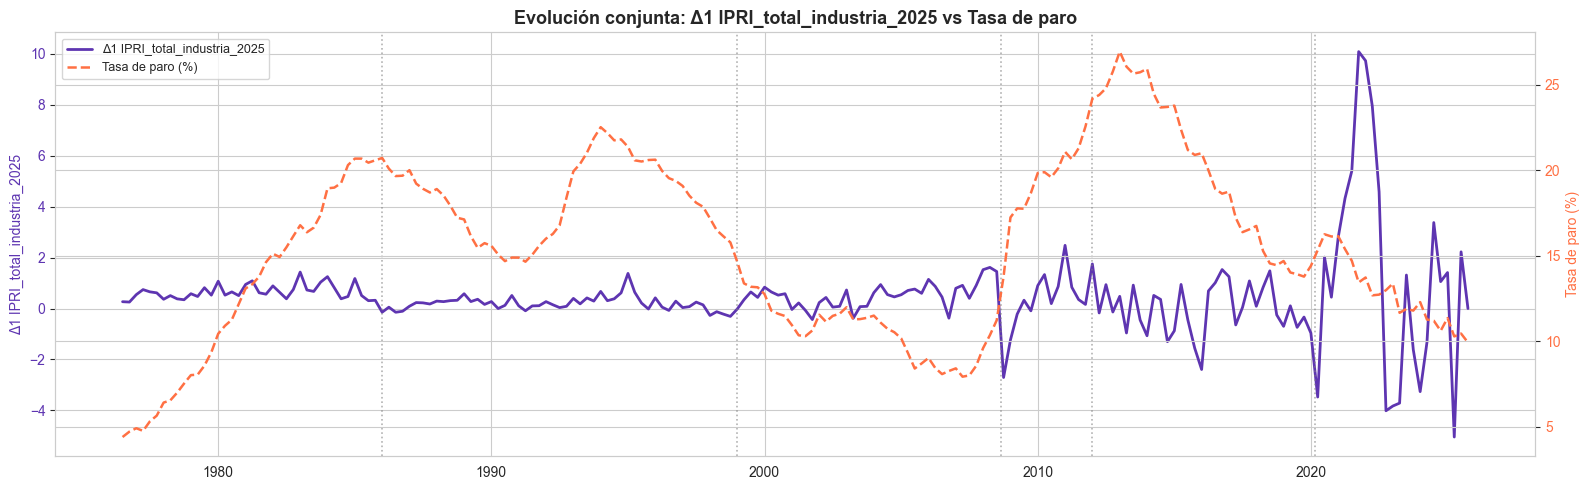

In [57]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

La evolución conjunta de `Δ1` `IPRI_total_industria_2025` y la tasa de paro confirma una relación débil y sin acoplamiento contemporáneo estable. La primera diferencia del IPRI es una señal de amplitud reducida y prácticamente plana hasta 2008 (oscila en una banda de ±1 punto de índice), mientras la tasa de paro recorre en ese tramo tres grandes ciclos (picos de aproximadamente 21% en 1985 y 24% en 1994, y un mínimo cercano al 8% en 2007) que no tienen reflejo proporcional en los cambios de precios industriales. Los grandes movimientos del desempleo de este periodo responden a factores estructurales (reconversión industrial, crisis del SME, burbuja inmobiliaria) ajenos a la dinámica de corto plazo del IPRI.

A partir de 2008 la amplitud de `Δ1` se incrementa de forma visible, con valores de hasta aproximadamente ±2,5 puntos, coherente con la heterocedasticidad documentada en el residuo STL y en la propia diferencia, pero sin que ese aumento de volatilidad se traduzca en co-movimiento con el paro. El episodio 2020-2022 expone la mayor desconexión de toda la muestra: `Δ1` registra el swing más extremo de la serie, con un máximo próximo a +10 puntos en agosto de 2022 y oscilaciones posteriores entre aproximadamente -4 y +3, mientras la tasa de paro apenas se altera (sube brevemente en 2020, amortiguada por los ERTEs, y continúa descendiendo durante todo el shock alcista del IPRI). El shock energético post-pandémico operó así como una perturbación de oferta exógena que se trasladó a los precios industriales sin el mecanismo de destrucción de empleo que acompañó a la crisis de 2008, anticipando una correlación global cercana a cero con posibles episodios breves de signo variable según el régimen.

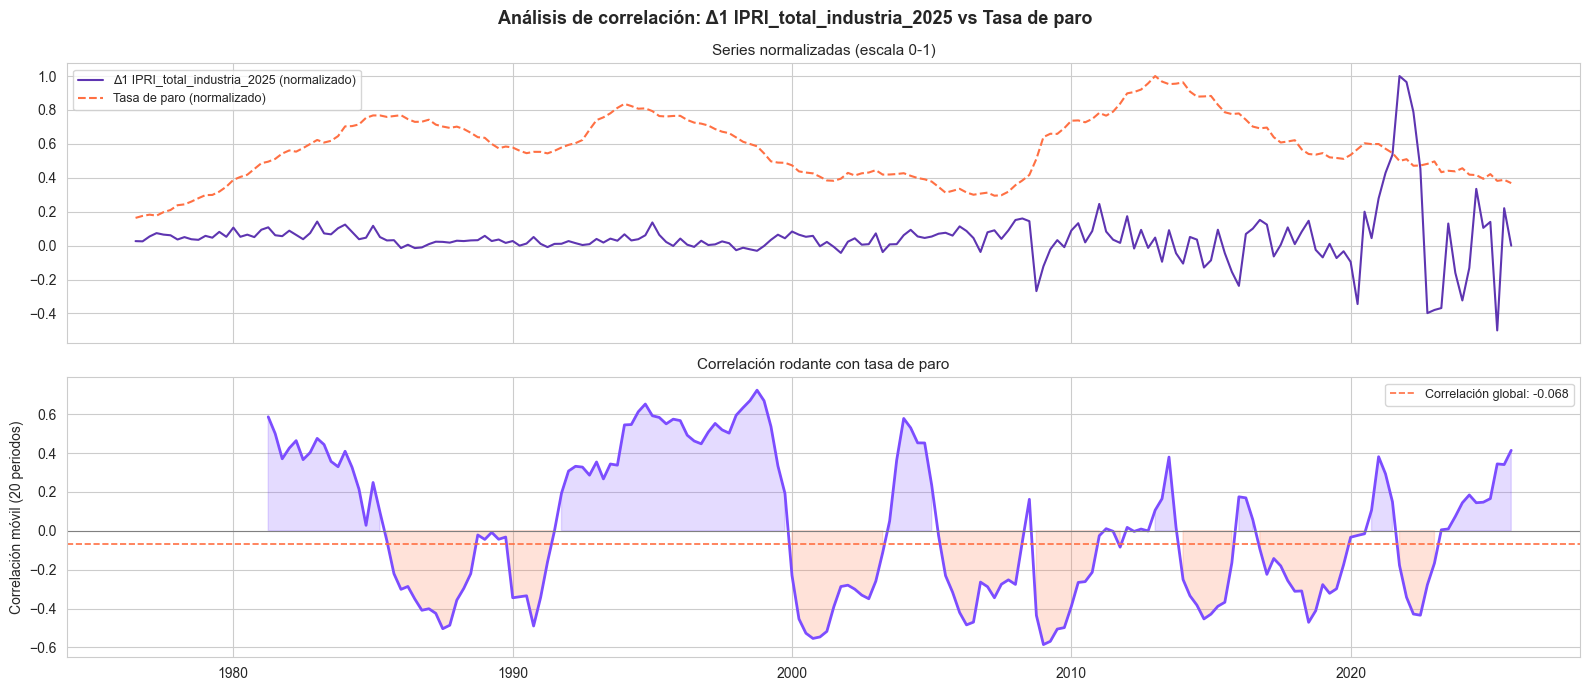

Correlación de Pearson global: -0.0683


In [58]:
ventana_corr = 20

df_cross = pd.DataFrame({'ipri': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['ipri'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['ipri'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['ipri'] / df_cross['ipri'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación global entre `Δ1` `IPRI_total_industria_2025` y la tasa de paro es de -0,0683, prácticamente nula, confirmando lo anticipado en el análisis de evolución conjunta y consistente con la débil relación de Phillips documentada para el `IPC_2025` (-0,267). El IPC mantiene una señal de correlación negativa algo más sistemática que el IPRI, coherente con el hecho de que el IPRI captura precios de producción industrial sensibles a shocks de oferta exógenos (energía, materias primas) que no se transmiten necesariamente a través del mercado de trabajo.

La correlación rodante a 20 trimestres muestra una inestabilidad de signo muy marcada, con alternancia entre regímenes positivos y negativos a lo largo de toda la muestra y oscilaciones que recorren desde aproximadamente +0,7 hasta -0,6. Se distinguen varios regímenes: positivo entre 1981 y 1985 (en torno a +0,6), negativo hacia 1988 (aproximadamente -0,5), un tramo positivo prolongado entre 1991 y 1999 que alcanza +0,7, fuertemente negativo en 2000-2003 (mínimo de aproximadamente -0,55 en 2001) y de nuevo en 2008 (aproximadamente -0,6), con alternancias menores posteriores y una recuperación hacia +0,4 al final de la muestra. Cada régimen tiene una duración de varios años y se ancla en un contexto macroeconómico identificable, de modo que la correlación global cercana a cero es el promedio de regímenes con signos opuestos, no evidencia de ausencia de relación.

Para la caracterización de la variable, este patrón implica que el `Δ1` `IPRI_total_industria_2025` no debe descartarse pese a su correlación global nula: su poder predictivo es condicional al régimen macroeconómico, lo que se documenta aquí como hallazgo y cuyo aprovechamiento se difiere a la fase de feature engineering. La curva de Phillips canónica, en cualquier caso, no se sostiene como representación estable de la relación entre los precios industriales y el desempleo en España.

In [59]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='ipri', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'ipri': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

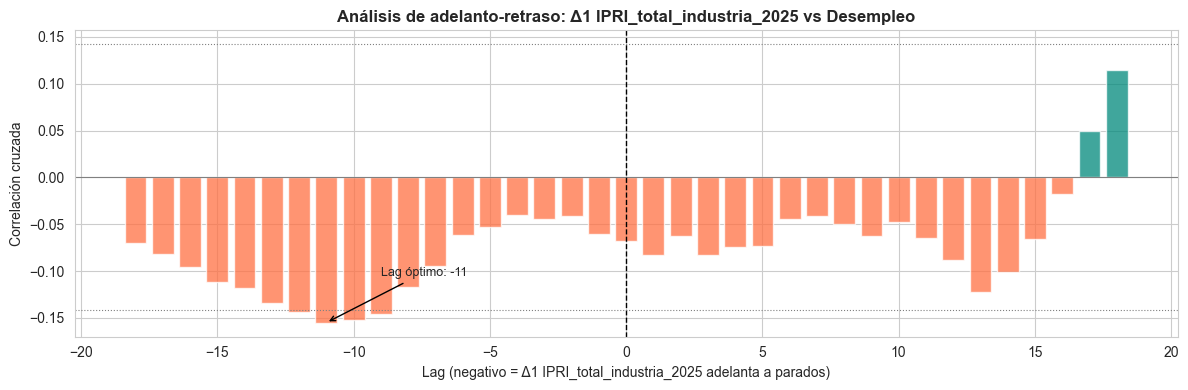

Lag con máxima correlación: -11 periodos
Correlación en ese lag: -0.1551
Banda de significancia (±2/√N): ±0.1421


In [60]:
max_lag = LAGS_ACF // 2

sa = (df_cross['ipri'] - df_cross['ipri'].mean()) / df_cross['ipri'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de adelanto-retraso confirma que la relación entre `Δ1` `IPRI_total_industria_2025` y la tasa de paro es débil en todos los horizontes y no ofrece un lag operativo aprovechable para la predicción a corto plazo. La correlación cruzada es negativa en casi todo el espectro de lags, con un único tramo positivo y muy pequeño en los lags +17 y +18, por debajo de la banda de significancia.

El lag óptimo se sitúa en -11 trimestres, con una correlación de -0,1551 que apenas supera la banda de significancia (±0,1421). Un lag negativo significa que el IPRI adelanta al paro: los cambios de precios industriales de hoy se asocian, con un retardo de aproximadamente 11 trimestres (cerca de tres años), a movimientos del desempleo de signo inverso, una lectura coherente con la lógica de Phillips de medio plazo. La señal, sin embargo, es débil y el horizonte de casi tres años convierte este lag en descriptivo de la relación estructural, no en un predictor operativo.

Los lags próximos a cero, los relevantes para la predicción a corto plazo del paro (del contemporáneo al -4), muestran correlaciones negativas mucho más débiles, en torno a -0,05 a -0,07, dentro de la banda y por tanto no distinguibles de cero. El `Δ1` del IPRI no aporta, por sí solo, señal predictiva apreciable sobre el paro en horizontes de uno a cuatro trimestres. Su valor es condicional al régimen y se concentra en episodios específicos (shocks de oferta, ciclos de materias primas); este carácter condicionado se documenta como hallazgo y su aprovechamiento se difiere a la fase de feature engineering, en coherencia con la correlación rodante por regímenes de la sección anterior.